In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from matplotlib.gridspec import GridSpec
DF_ZIKO = pd.read_csv('ziko_data.csv')


/var/folders/92/g_kswjtn2kd1qpqpdgl_k9xm0000gp/T/ipykernel_84042/519135076.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, patch_artist=True, labels=['ziko', 'rand_inf'])
/var/folders/92/g_kswjtn2kd1qpqpdgl_k9xm0000gp/T/ipykernel_84042/519135076.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, patch_artist=True, labels=['ziko', 'rand_inf'])
/var/folders/92/g_kswjtn2kd1qpqpdgl_k9xm0000gp/T/ipykernel_84042/519135076.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, patch_artist=True, labels=['ziko', 'rand_inf'])
/var/folders/92/

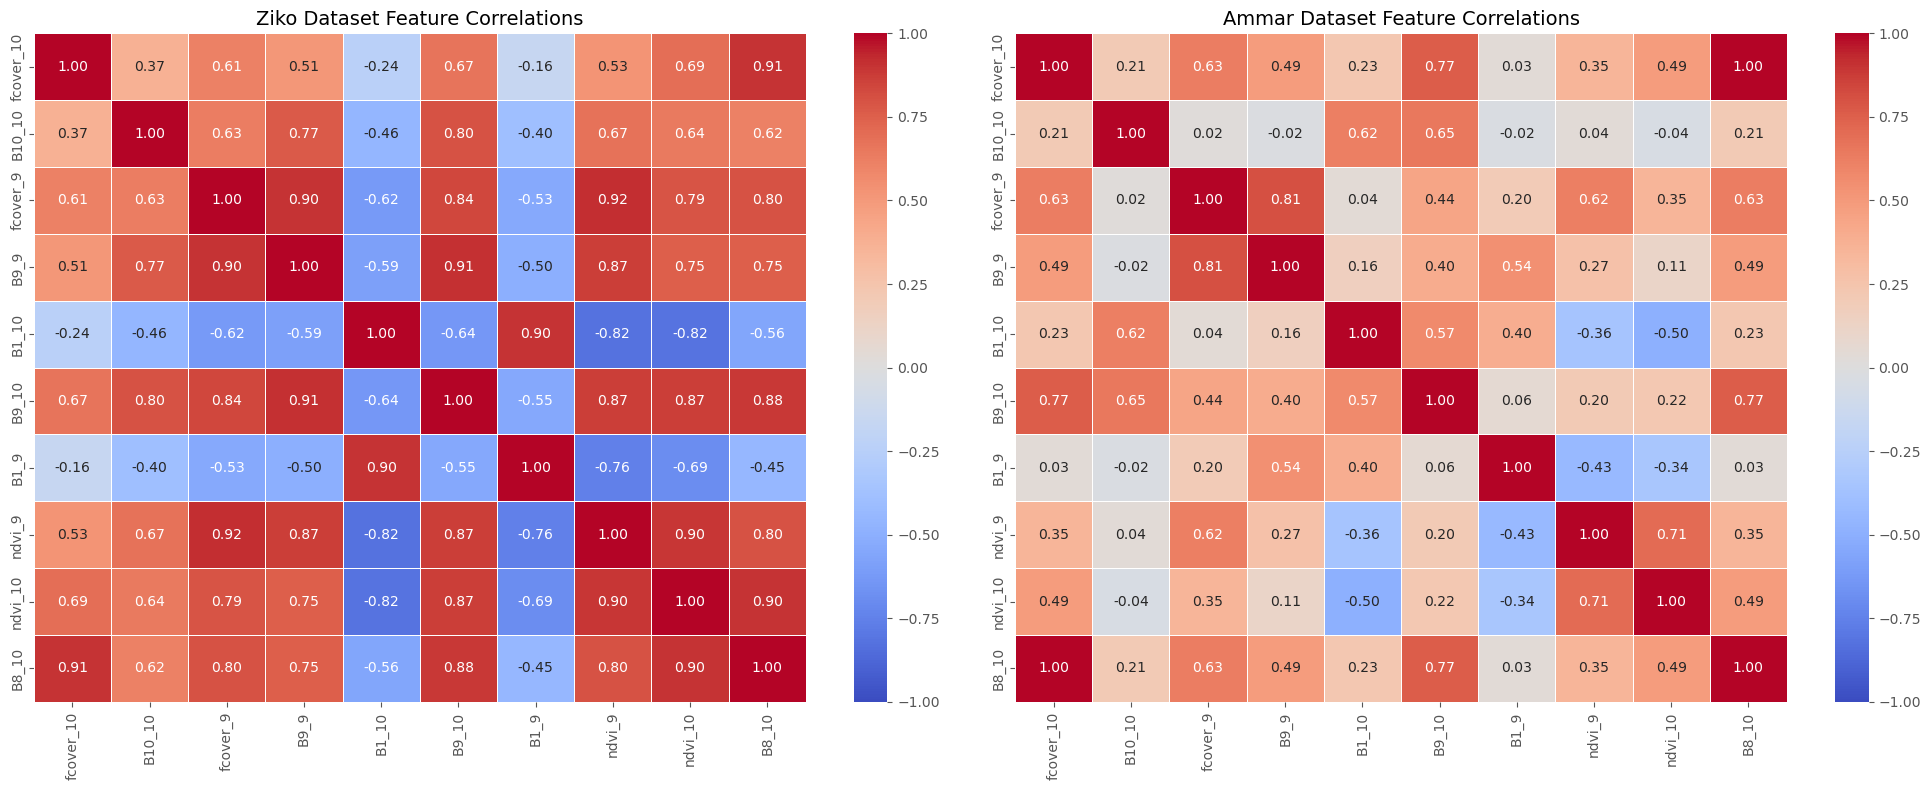

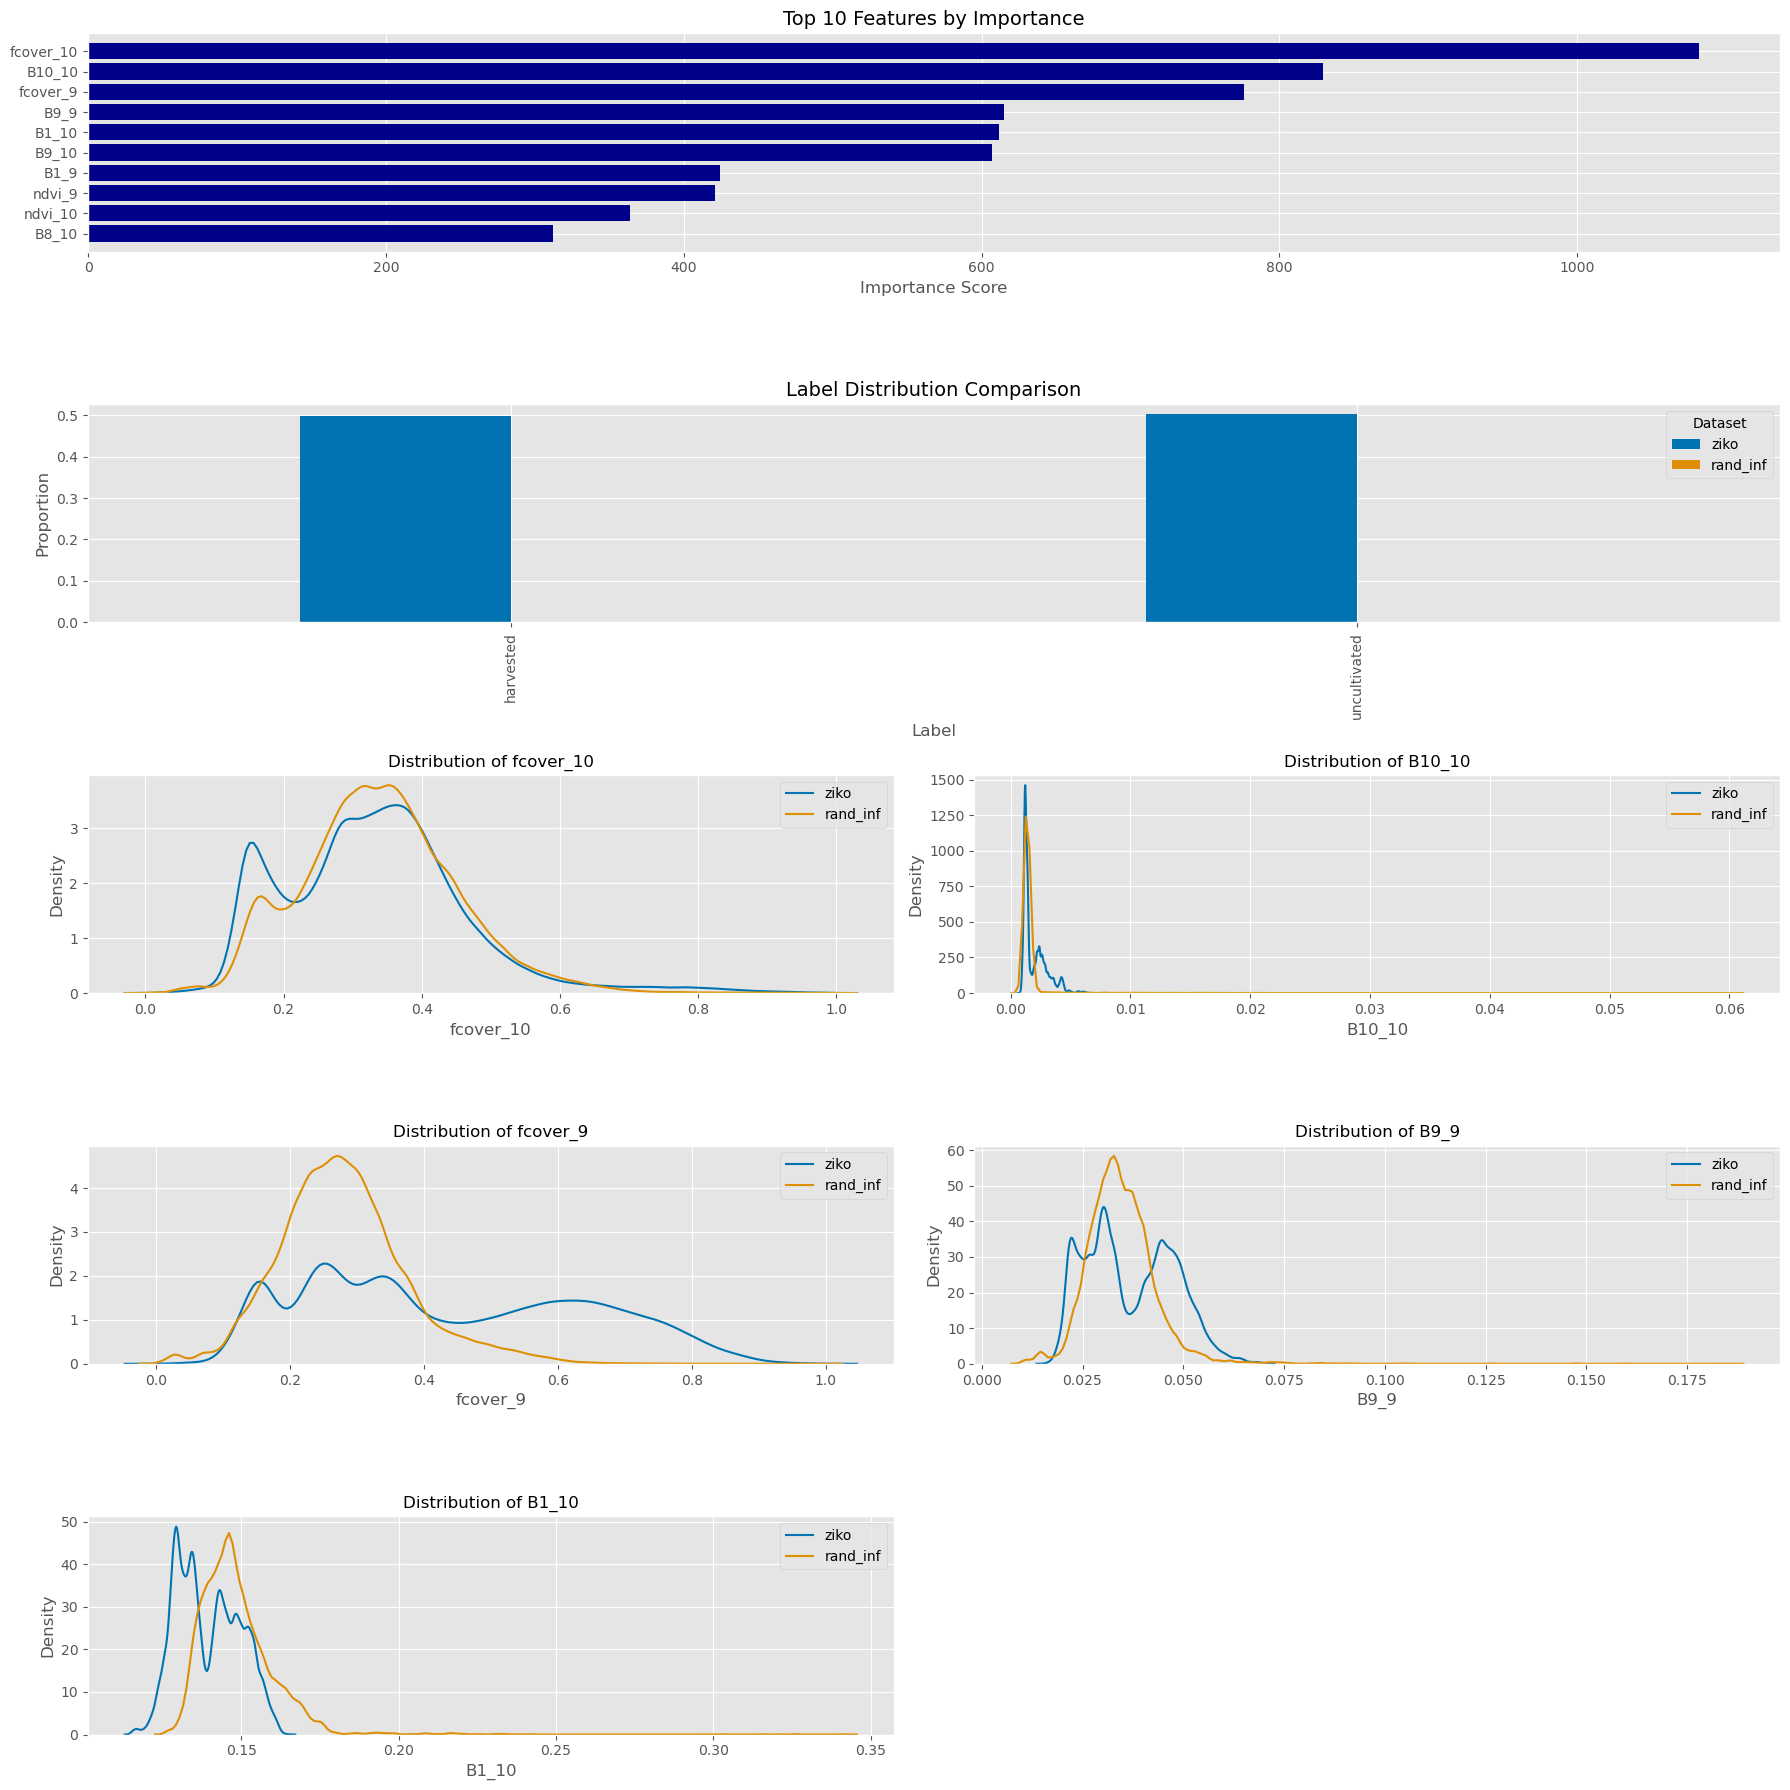

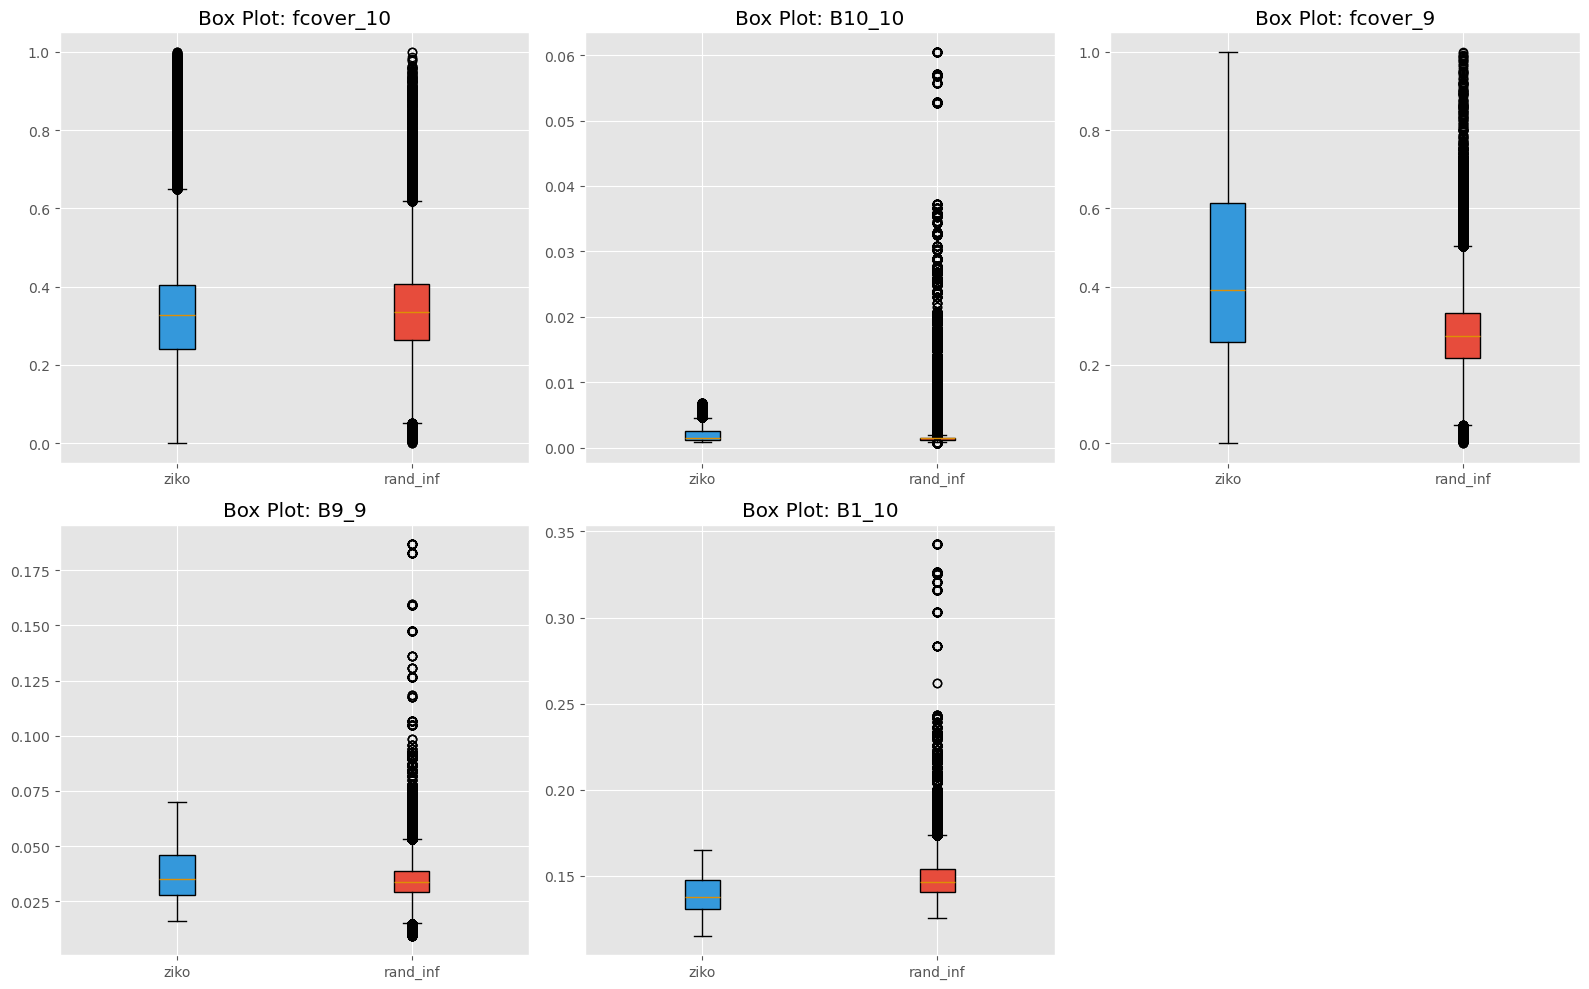

<Figure size 1400x800 with 0 Axes>

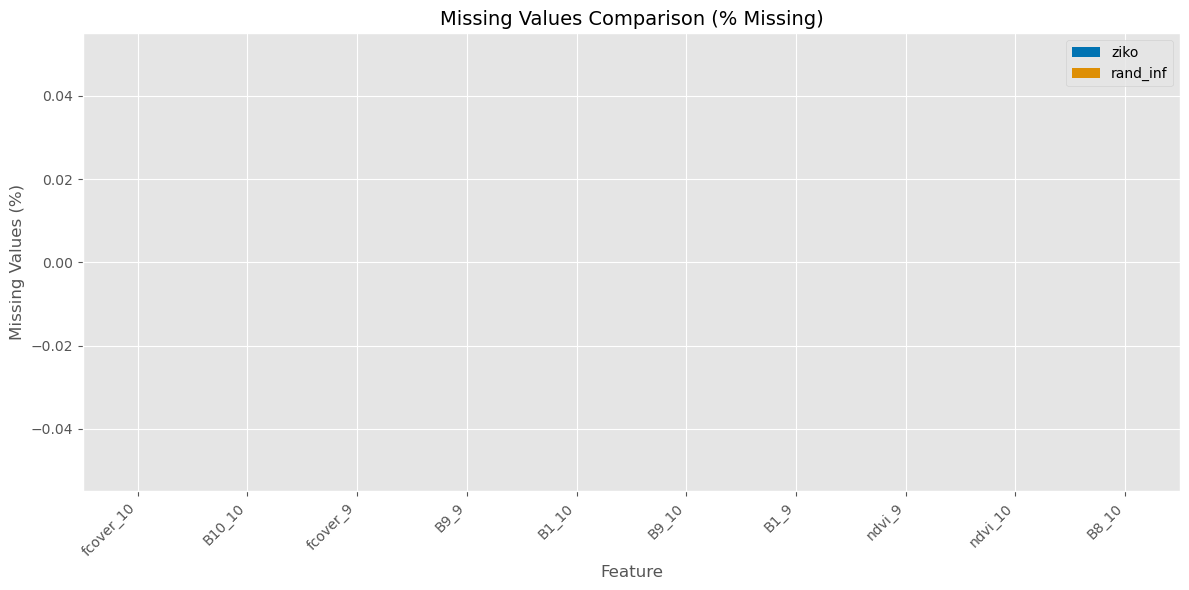

In [8]:


# Set style for better visualizations
plt.style.use('ggplot')
sns.set_palette("colorblind")

# Load both datasets
df_ziko = pd.read_csv('ziko_data.csv')
year = 2021
df_ziko = DF_ZIKO[DF_ZIKO["year"]==year].copy()
df_ammar = pd.read_csv(f'./hussam_inf_samples/combined_infra_{year}_data.csv')  # Renamed from df_2023 to df_ammar
label_map = {
    "uncultivated":"uncultivated",
    "cultivated": "harvested",
    "harvested": "harvested"
}
df_ammar["label"] = None
# df_ammar["label"] = [label_map[l] for l in df_ammar["label"]]

# Load the model to extract feature importance
model = xgb.Booster()
model.load_model('xgboost_model.json')

# Get feature names and importance scores
importance = model.get_score(importance_type='weight')
top_features = sorted(importance, key=importance.get, reverse=True)[:10]  # Top 10 features

# Create a figure with subplots
plt.figure(figsize=(18, 18))
gs = GridSpec(5, 2, figure=plt.gcf())

# 1. Feature Importance Plot
ax1 = plt.subplot(gs[0, :])
importance_values = [importance[feat] for feat in top_features]
ax1.barh(top_features, importance_values, color='darkblue')
ax1.set_title('Top 10 Features by Importance', fontsize=14)
ax1.set_xlabel('Importance Score')
ax1.invert_yaxis()  # Display highest importance at top

# 2. Class Distribution Comparison
ax2 = plt.subplot(gs[1, :])
label_counts_ziko = df_ziko['label'].value_counts(normalize=True)
label_counts_ammar = df_ammar['label'].value_counts(normalize=True)

# Create a DataFrame for easier plotting
label_df = pd.DataFrame({
    'ziko': label_counts_ziko,
    'rand_inf': label_counts_ammar
})
label_df.plot(kind='bar', ax=ax2)
ax2.set_title('Label Distribution Comparison', fontsize=14)
ax2.set_xlabel('Label')
ax2.set_ylabel('Proportion')
ax2.legend(title='Dataset')

# 3. Feature Distribution Comparison for Top 5 Features
for i, feature in enumerate(top_features[:5]):  # Just using top 5 to avoid cluttering
    if feature in df_ziko.columns and feature in df_ammar.columns:
        # Determine plot location (2 features per row starting from row 2)
        row = 2 + i // 2
        col = i % 2
        
        ax = plt.subplot(gs[row, col])
        
        # Create density plots for both datasets
        sns.kdeplot(df_ziko[feature].dropna(), label='ziko', ax=ax)
        sns.kdeplot(df_ammar[feature].dropna(), label='rand_inf', ax=ax)
        
        ax.set_title(f'Distribution of {feature}', fontsize=12)
        ax.set_xlabel(feature)
        ax.set_ylabel('Density')
        ax.legend()

# 4. Create Box Plots for Feature Comparisons
plt.figure(figsize=(16, 10))

# Choose top 5 features for box plot comparison
for i, feature in enumerate(top_features[:5]):
    if feature in df_ziko.columns and feature in df_ammar.columns:
        plt.subplot(2, 3, i+1)
        
        # Prepare data for boxplot
        box_data = [
            df_ziko[feature].dropna(),
            df_ammar[feature].dropna()
        ]
        
        # Create box plot
        bp = plt.boxplot(box_data, patch_artist=True, labels=['ziko', 'rand_inf'])
        
        # Change colors
        colors = ['#3498db', '#e74c3c']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            
        plt.title(f'Box Plot: {feature}')
        plt.tight_layout()

# 5. Missing Values Comparison
plt.figure(figsize=(14, 8))
common_features = [f for f in top_features if f in df_ziko.columns and f in df_ammar.columns]

# Calculate missing percentages
missing_ziko = [df_ziko[f].isna().mean() * 100 for f in common_features]
missing_ammar = [df_ammar[f].isna().mean() * 100 for f in common_features]

# Create a DataFrame for comparison
missing_df = pd.DataFrame({
    'ziko': missing_ziko,
    'rand_inf': missing_ammar
}, index=common_features)

missing_df.plot(kind='bar', figsize=(12, 6))
plt.title('Missing Values Comparison (% Missing)', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Missing Values (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 6. Feature Correlation Heatmap Comparison
plt.figure(figsize=(20, 8))

# Limit to common top features that are numeric
numeric_features = [f for f in common_features 
                   if pd.api.types.is_numeric_dtype(df_ziko[f]) and pd.api.types.is_numeric_dtype(df_ammar[f])]

# Ziko correlation heatmap
plt.subplot(1, 2, 1)
corr_ziko = df_ziko[numeric_features].corr()
sns.heatmap(corr_ziko, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Ziko Dataset Feature Correlations', fontsize=14)

# Ammar correlation heatmap
plt.subplot(1, 2, 2)
corr_ammar = df_ammar[numeric_features].corr()
sns.heatmap(corr_ammar, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Ammar Dataset Feature Correlations', fontsize=14)
plt.tight_layout()

# Save all figures
plt.figure(1)
plt.tight_layout()
plt.savefig('feature_importance_and_distributions.png', dpi=300)

plt.figure(2)
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=300)

plt.figure(3)
plt.tight_layout()
plt.savefig('missing_values_comparison.png', dpi=300)

plt.figure(4)
plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=300)

# Show all plots
plt.show()